In [15]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import random
import seaborn as sns
import numpy as np

In [4]:
base_dir = '/kaggle/input/ai-generated-images-vs-real-images'
splits = ['train', 'test']
classes = ['real', 'fake']

data = []

for split in splits:
    for cls in classes:
        folder = os.path.join(base_dir, split, cls)
        for fname in os.listdir(folder):
            if fname.lower().endswith(('.jpg','.jpeg','.png')):
                data.append({
                    'path': os.path.join(folder, fname),
                    'split': split,
                    'label': cls
                })

df = pd.DataFrame(data)

In [5]:
train_df = df[df['split']=='train']
test_df = df[df['split']=='test']

train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['label'], random_state=42)

In [6]:
def count_labels(df):
    real = (df['label']=='real').sum()
    fake = (df['label']=='fake').sum()
    total = len(df)
    return pd.Series([real, fake, total], index=['Real Images','Fake Images','Total Count'])

# Prepare table
summary = pd.DataFrame({
    'Training': count_labels(train_df),
    'Validation': count_labels(val_df),
    'Test': count_labels(test_df)
}).T  # transpose to match your format

# Add total row
summary.loc['Total'] = summary.sum()

# Display nicely
print(summary)

            Real Images  Fake Images  Total Count
Training          19200        19200        38400
Validation         4800         4800         9600
Test               6000         6000        12000
Total             30000        30000        60000


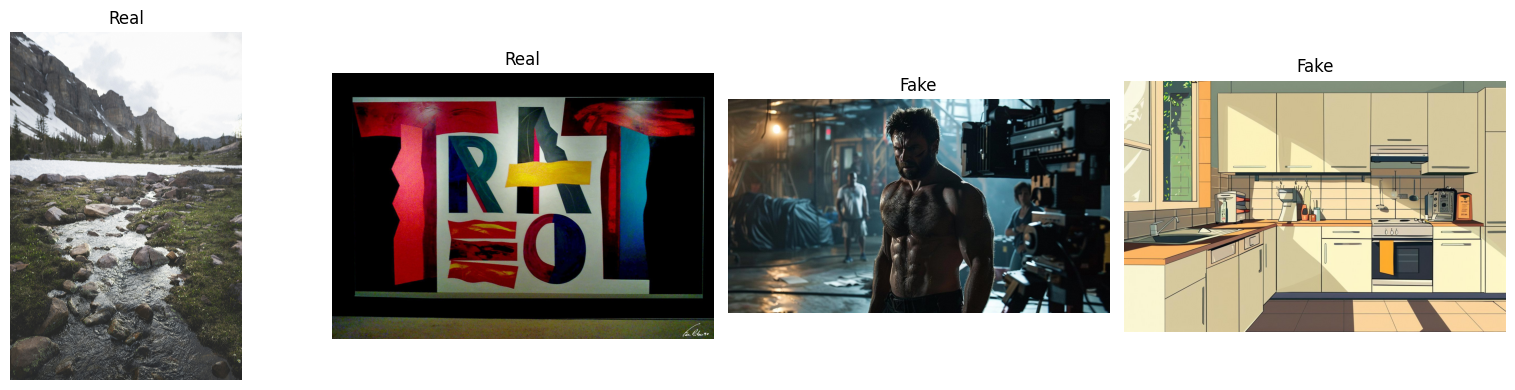

In [9]:
# Select 2 random images from each class
def sample_images(df, label, n=2):
    return df[df['label'] == label].sample(n)['path'].tolist()

real_imgs = sample_images(train_df, 'real', 2)
fake_imgs = sample_images(train_df, 'fake', 2)

all_imgs = real_imgs + fake_imgs
all_labels = ['Real', 'Real', 'Fake', 'Fake']

# Plot images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img_path, label in zip(axes, all_imgs, all_labels):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

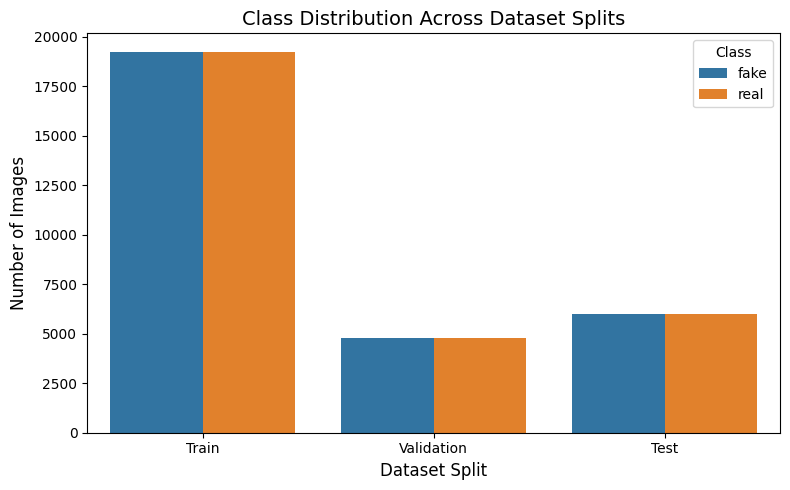

In [12]:
# Prepare data
train_counts = train_df['label'].value_counts()
val_counts = val_df['label'].value_counts()
test_counts = test_df['label'].value_counts()

dist_df = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
}).T.reset_index().melt(id_vars='index', var_name='Class', value_name='Count')
dist_df.rename(columns={'index': 'Split'}, inplace=True)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='Split', y='Count', hue='Class', data=dist_df, palette=['#1f77b4', '#ff7f0e'])
plt.title('Class Distribution Across Dataset Splits', fontsize=14)
plt.ylabel('Number of Images', fontsize=12)
plt.xlabel('Dataset Split', fontsize=12)
plt.legend(title='Class')
plt.tight_layout()
plt.show()

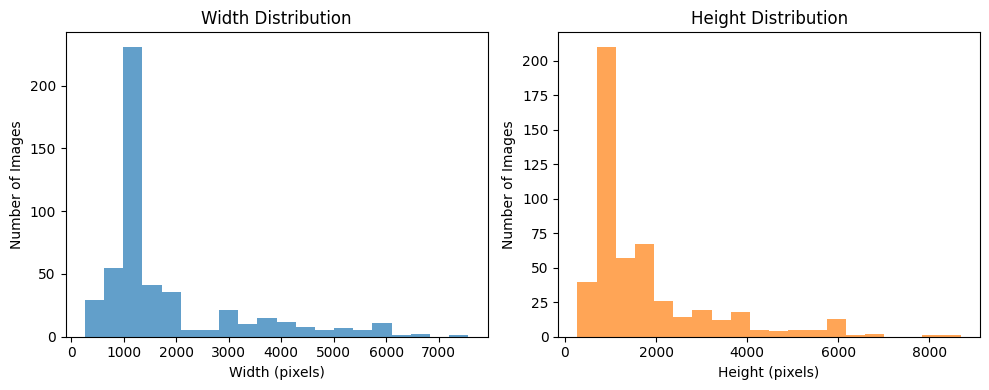

In [13]:
# Get image resolutions
resolutions = []
for path in df['path'].sample(500, random_state=42):  # sample for speed
    img = Image.open(path)
    resolutions.append(img.size)  # (width, height)

# Separate width and height
widths, heights = zip(*resolutions)

# Plot histograms
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(widths, bins=20, color='#1f77b4', alpha=0.7)
plt.title('Width Distribution')
plt.xlabel('Width (pixels)')
plt.ylabel('Number of Images')

plt.subplot(1,2,2)
plt.hist(heights, bins=20, color='#ff7f0e', alpha=0.7)
plt.title('Height Distribution')
plt.xlabel('Height (pixels)')
plt.ylabel('Number of Images')

plt.tight_layout()
plt.show()


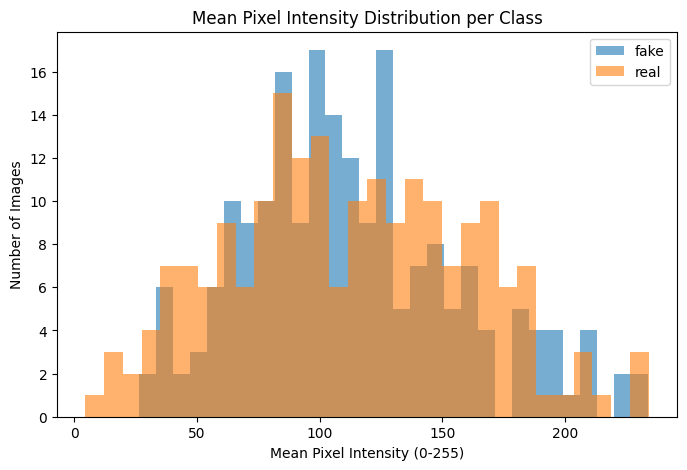

In [16]:
# Function to compute mean pixel intensity of an image
def mean_intensity(img_path):
    img = Image.open(img_path).convert('L')  # convert to grayscale
    arr = np.array(img)
    return arr.mean()

# Sample for speed (optional)
sample_df = train_df.groupby('label').sample(n=200, random_state=42)  # 200 per class

# Compute mean intensity
mean_intensities = sample_df.copy()
mean_intensities['mean_pixel'] = mean_intensities['path'].apply(mean_intensity)

# Plot distribution
plt.figure(figsize=(8,5))
for label in mean_intensities['label'].unique():
    subset = mean_intensities[mean_intensities['label']==label]
    plt.hist(subset['mean_pixel'], bins=30, alpha=0.6, label=label)

plt.title('Mean Pixel Intensity Distribution per Class')
plt.xlabel('Mean Pixel Intensity (0-255)')
plt.ylabel('Number of Images')
plt.legend()
plt.show()


In [65]:
# Augmented training transform: adds flips, rotation, color jitter
transform_train_aug = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),    
    transforms.RandomVerticalFlip(p=0.5),      
    transforms.RandomRotation(15),            
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

# -----------------------------
# Validation / Test Transforms
# -----------------------------
# Only deterministic preprocessing: resize + normalize
transform_eval = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

In [66]:
class AiVsRealDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = 0 if row['label']=='real' else 1
        return img, label

In [67]:
train_dataset = AiVsRealDataset(train_df, transform=transform_train_aug)  # augmented for train
val_dataset   = AiVsRealDataset(val_df, transform=transform_eval)        # eval only
test_dataset  = AiVsRealDataset(test_df, transform=transform_eval)       # eval only

# -----------------------------
# Create DataLoaders
# -----------------------------
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print('Data Loaders ready !!')

Data Loaders ready !!


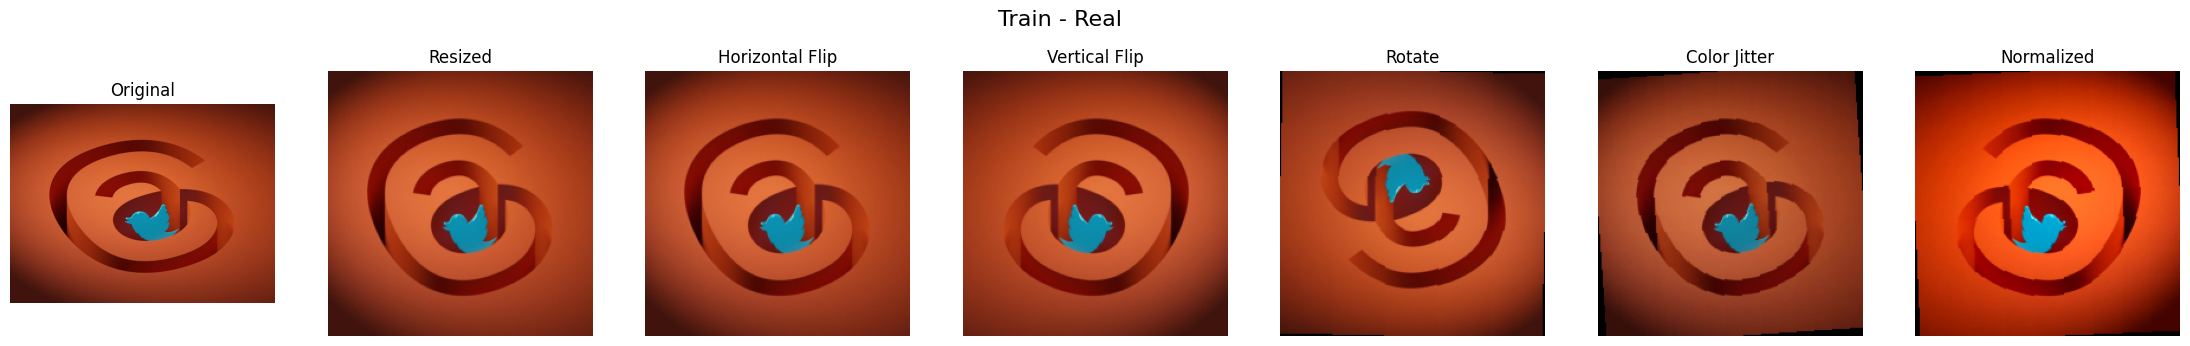

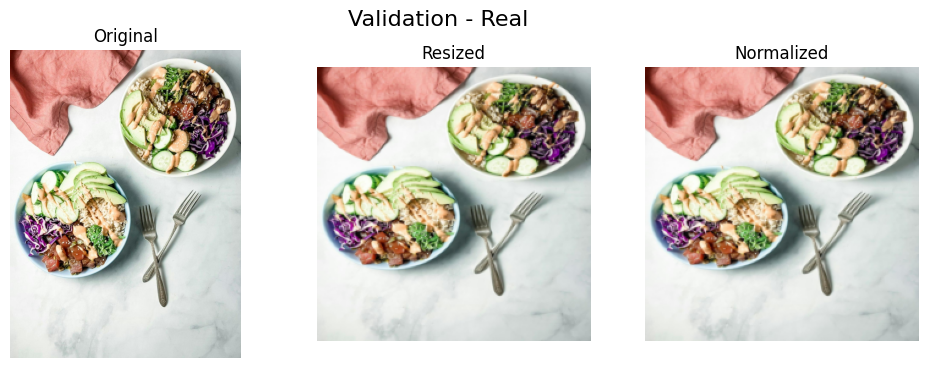

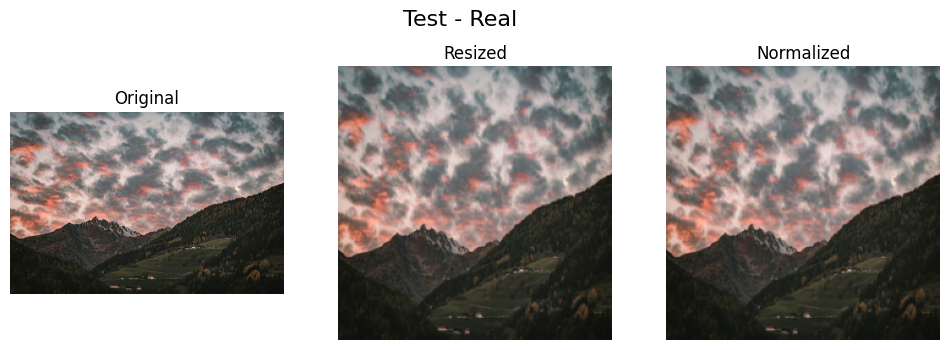

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

# Function to visualize multiple variants side by side
def show_variants(image_path, label, transforms_dict):
    n = len(transforms_dict)
    fig, axes = plt.subplots(1, n, figsize=(4*n,4))
    
    # Handle single Axes
    if n == 1:
        axes = [axes]
    
    for ax, (name, trans) in zip(axes, transforms_dict.items()):
        img = Image.open(image_path).convert('RGB')
        if trans:
            img_t = trans(img)
            if isinstance(img_t, torch.Tensor):
                img_t = img_t.permute(1,2,0).numpy()
                # Denormalize for display
                img_t = img_t * 0.5 + 0.5
                img_t = img_t.clip(0,1)
        else:
            img_t = np.array(img)/255.0
        ax.imshow(img_t)
        ax.set_title(name)
        ax.axis('off')
    
    fig.suptitle(f"{label}", fontsize=16)
    plt.show()

# -----------------------------
# Preprocessing variants per split
# -----------------------------

train_variants = {
    "Original": transforms.Compose([]),
    "Resized": transforms.Resize((224,224)),
    "Horizontal Flip": transforms.Compose([transforms.Resize((224,224)),
                                           transforms.RandomHorizontalFlip(p=0.5)]),
    "Vertical Flip": transforms.Compose([transforms.Resize((224,224)),
                                         transforms.RandomHorizontalFlip(p=0.5),
                                         transforms.RandomVerticalFlip(p=0.5)]),
    "Rotate": transforms.Compose([transforms.Resize((224,224)),
                                  transforms.RandomHorizontalFlip(p=0.5),
                                  transforms.RandomVerticalFlip(p=0.5),
                                  transforms.RandomRotation(15)]),
    "Color Jitter": transforms.Compose([transforms.Resize((224,224)),
                                        transforms.RandomHorizontalFlip(p=0.5),
                                  transforms.RandomVerticalFlip(p=0.5),
                                  transforms.RandomRotation(15),
                                        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)]),
    "Normalized": transform_train_aug
}

val_test_variants = {
    "Original": transforms.Compose([]),
    "Resized": transforms.Resize((224,224)),
    "Normalized": transform_eval
}

# Reset index to ensure boolean indexing works
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# -----------------------------
# Pick one real sample from each split
# -----------------------------
sample_train = train_df[train_df['label']=='real'].sample(1, random_state=42).iloc[0]
sample_val   = val_df[val_df['label']=='real'].sample(1, random_state=42).iloc[0]
sample_test  = test_df[test_df['label']=='real'].sample(1, random_state=42).iloc[0]

# -----------------------------
# Visualize each split
# -----------------------------
show_variants(sample_train['path'], "Train - Real", train_variants)
show_variants(sample_val['path'], "Validation - Real", val_test_variants)
show_variants(sample_test['path'], "Test - Real", val_test_variants)
